<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro14YOLO/yolo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
# import numpy as np
# import sys
# import subprocess

# try:
#    from ultralytics import YOLO
#    print('ultralytics가 설치됨')
# except ModuleNotFoundError:
#   print('ultralytics가 설치되지 않음')
#   try:
#       subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics', 'opencv-python'])
#       print('ultralytics 및 opencv-python 설치 완료')
#   except subprocess.CalledProcessError as e:
#     raise SystemExit(f'ultralytics 설치 실패 : {e}')

#   from ultralytics import YOLO

!pip install ultralytics opencv-python

In [34]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.6/107.7 GB disk)


In [40]:
# YOLO11 모델로 이미지 감지
from ultralytics import YOLO

print(ultralytics.__version__)

model = YOLO('yolo11n.pt')  # nano version : s, m, i ...
print(model.names, len(model.names))  # COCO dataset으로 학습된 모델이므로 라벨 80개가 있다.

8.4.51
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 

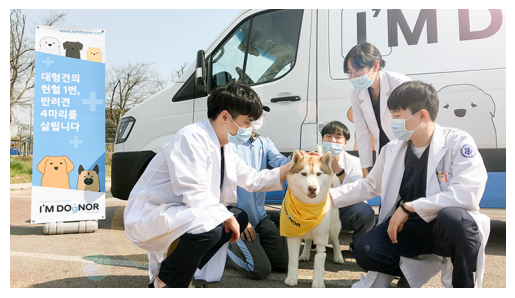

In [41]:
# 이미지 로딩 후 감지
from PIL import Image
import matplotlib.pyplot as plt
import sys

# image_path = 'test_aug.jpg'
image_path = 'images.jpg'

try:
  image = Image.open(image_path)
  plt.imshow(image)
  plt.axis('off')
  plt.show()
except Exception as e:
  print('load err :', e)
  sys.exit()


0: 384x640 6 persons, 1 car, 1 bus, 1 truck, 1 dog, 1 tie, 283.4ms
Speed: 14.3ms preprocess, 283.4ms inference, 12.8ms postprocess per image at shape (1, 3, 384, 640)
(400, 712)
image.shape :  (400, 712, 3)
image[0, 0] :  [217 226 233]


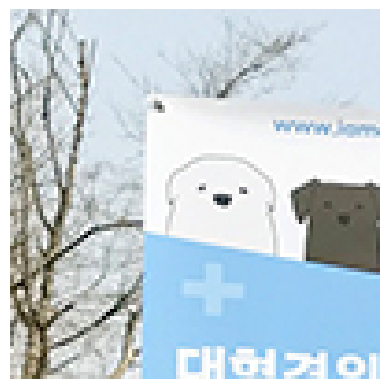

In [42]:
# 객체 감지
import cv2
import numpy as np

try:
  # results = model(image)
  results = model(image, conf=0.25)
  # print(results)
  print(results[0].orig_shape)
except Exception as e:
  print('inference err : {e}')
  sys.exit()

image = np.array(image)   # Pillow이미지 -> image.open() -> np.array()하면 (H, W, 3)형태의 넘파이 배열이 됨
print('image.shape : ', image.shape)
# print('image[:5, :5] : ', image[:5, :5])
print('image[0, 0] : ', image[0,0])

# 이미지 영역 자르기
cropped = image[:100, :100]
plt.imshow(cropped)
plt.axis('off')
plt.show()

457 104 690 397
person
box.conf[0] : tensor(0.9269)
confidence : 0.9268688559532166
162 105 405 397
person
box.conf[0] : tensor(0.7786)
confidence : 0.7785943150520325
477 45 564 239
person
box.conf[0] : tensor(0.7371)
confidence : 0.7371470332145691
302 120 407 389
person
box.conf[0] : tensor(0.5222)
confidence : 0.5222389101982117
144 0 699 280
bus
box.conf[0] : tensor(0.4019)
confidence : 0.4018544554710388
442 159 507 256
person
box.conf[0] : tensor(0.3708)
confidence : 0.37081217765808105
0 199 14 211
car
box.conf[0] : tensor(0.3684)
confidence : 0.36836886405944824
141 1 704 378
truck
box.conf[0] : tensor(0.3663)
confidence : 0.3662949204444885
511 105 538 213
tie
box.conf[0] : tensor(0.3318)
confidence : 0.33183085918426514
386 201 481 398
dog
box.conf[0] : tensor(0.3291)
confidence : 0.32907506823539734
385 158 509 375
person
box.conf[0] : tensor(0.2783)
confidence : 0.2782643735408783
cat_detected : False


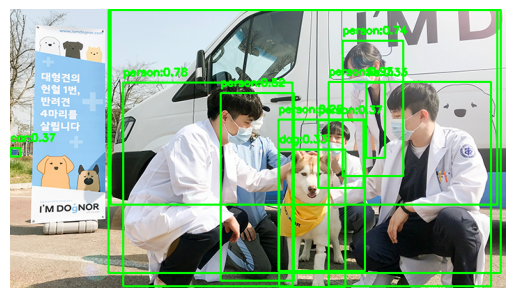

In [43]:
# 이미지 채우기
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

cat_detected = False  # cat 감지 여부 판단용 함수

for result in results:
  try:
    for box in result.boxes:   # 감지된 객체들의 바운딩 박스 리스트
      x1, y1, x2, y2 = map(int, box.xyxy[0])  # 바운딩 박스 좌표 반환
      print(x1, y1, x2, y2)
      label = result.names[int(box.cls[0])]   # 감지된 객체 클래스 이름 얻기
      print(label)

      print('box.conf[0] :', box.conf[0])   # tensor(0.5912)
      confidence = box.conf[0].item()   # 신뢰도(바운딩 박스 안에 해당 클래스가 실제로 있을 확률 값)
      print('confidence :', confidence)

      if label == 'cat' and confidence >= 0.4:
        cat_detected=True

      # 바운딩 박스 그리기
      cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)    # (R, G, B), 선 두께
      cv2.putText(image, f'{label}:{confidence:.2f}', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

  except Exception as e:
    print('process error :', e)

print('cat_detected :', cat_detected)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## YOLO confidence 계산 원리
YOLO는 한 개의 박스(box)에 대해 크게 두 가지를 예측한다:
1) Objectness Score :  이 박스 안에 “물체가 있을 확률”.  범위: 0 ~ 1
   예: 0.9 → 90% 확률로 뭔가 물체가 있음
2) Class Probability Distribution :  그 물체가 어떤 클래스인지의 확률 분포
   softmax나 sigmoid를 통해 각 클래스별 확률을 출력
   예: {dog: 0.8, cat: 0.15, person: 0.05}

최종 Confidence 수식
 YOLO는 특정 클래스 c에 대해 Confidence(box, c) = P(object) × P(class=c ∣ object)
 즉, 물체가 있을 확률 × 그 물체가 특정 클래스일 확률로 계산한다.

예) Objectness = 0.9, Class probabilities = {dog: 0.8, cat: 0.15, person: 0.05}
     dog 클래스의 confidence는 0.9×0.8=0.72
     따라서 출력은  dog: 0.72,  cat: 0.135,  person: 0.045

In [39]:
if label == 'cat' and confidence >= 0.4:
  print('고양이가 보여요')

# 감지 결과를 파일로 저장
cv2.imwrite('yolo1out.jpg', image)

# colab에서 저장한 이미지 다운로드할 경우
from google.colab import files
files.download('yolo1out.jpg')

고양이가 보여요


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>